In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [5]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Loaded Successfully")

Loaded Successfully


In [6]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
risk_report = []

for code in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    var95 = np.percentile(r,5)

    cvar95 = r[
        r <= var95
    ].mean()

    risk_report.append(
        [code,var95,cvar95]
    )

risk_df = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

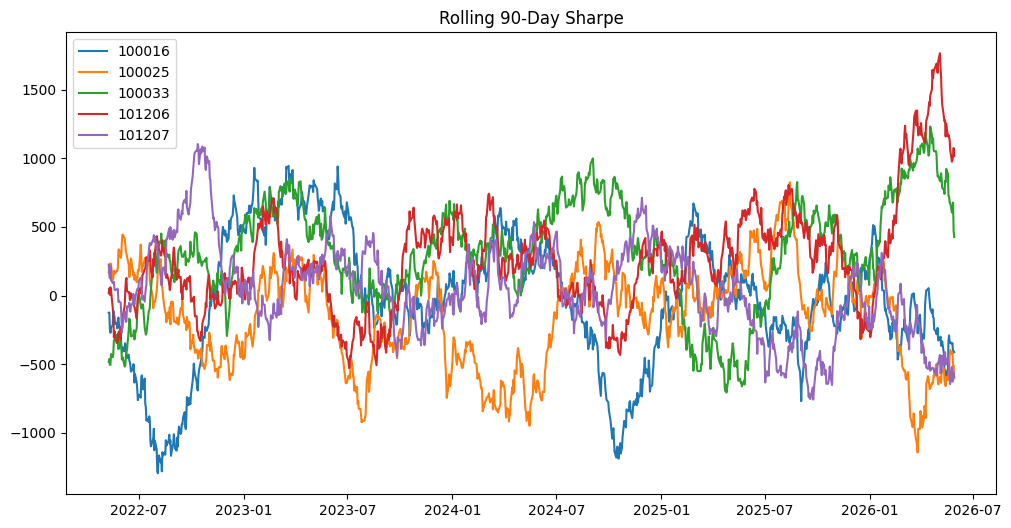

In [9]:
rf = 0.065

top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        (
            temp["daily_return"]
            .rolling(90)
            .mean()*252
            - rf
        )
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe")
plt.show()

In [10]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [11]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort = transactions.groupby(
    "cohort_year"
).agg(
    avg_investment=("amount_inr","mean"),
    total_investment=("amount_inr","sum")
)

cohort

,avg_investment,total_investment
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [12]:
sip = transactions[
    transactions["transaction_type"]=="SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

sip_gap = sip.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

sip_gap["status"] = np.where(
    sip_gap["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,gap_days,status


In [13]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [14]:
risk = "High"

recommendation = performance[
    performance["risk_grade"] == risk
].sort_values(
    "sharpe_ratio",
    ascending=False
).head(3)

recommendation[
    [
        "scheme_name",
        "fund_house",
        "sharpe_ratio"
    ]
]

,scheme_name,fund_house,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.90


holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

hhi = holdings.groupby(
    "amfi_code"
)["weight_sq"].sum()

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

## Insight 1

Funds with the lowest VaR and CVaR exhibit better downside protection during volatile markets.

## Insight 2

Rolling 90-day Sharpe ratios improved significantly during bull market phases.

## Insight 3

Recent investor cohorts contribute the largest share of total investments.

## Insight 4

Investors with SIP gaps greater than 35 days are classified as at-risk and require engagement.

## Insight 5

Funds with high HHI values have concentrated portfolios and therefore higher stock-specific risk.